**1: Install/import libraries**

In [1]:
# pandas for loading and manipulating tabular data
import pandas as pd
# numpy for numerical operations
import numpy as np

# train_test_split splits data into training and testing sets
from sklearn.model_selection import train_test_split, GridSearchCV
# Pipeline chains preprocessing + model into one reusable object
from sklearn.pipeline import Pipeline
# ColumnTransformer applies different preprocessing to different column types
from sklearn.compose import ColumnTransformer
# StandardScaler scales numeric features, OneHotEncoder encodes categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# SimpleImputer fills in missing values
from sklearn.impute import SimpleImputer
# Two models we'll compare: Logistic Regression and Random Forest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Metrics to evaluate classification performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
# joblib to export/save the final trained pipeline to disk
import joblib
# Plotting library for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

**2: Load the Telco Churn dataset**

In [2]:
# This is IBM's public Telco Customer Churn dataset, hosted on GitHub as a raw CSV
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Load it directly into a pandas DataFrame
df = pd.read_csv(url)

# Show shape (rows, columns) to confirm it loaded correctly
print("Shape:", df.shape)

# Preview the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**3: Explore and clean the data**

In [3]:
# Check data types and non-null counts for every column
df.info()

# customerID is just an identifier, not predictive — drop it
df = df.drop(columns=["customerID"])

# TotalCharges is read as text/object because of some blank strings — convert to numeric
# errors="coerce" turns any non-numeric value (like blank " ") into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many missing values this created
print("Missing values in TotalCharges:", df["TotalCharges"].isna().sum())

# Convert the target column "Churn" from Yes/No strings into 1/0 integers
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Confirm class balance of the target — churn datasets are usually imbalanced
print(df["Churn"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**4: Split features and target**

In [4]:
# X = all columns except the target
X = df.drop(columns=["Churn"])
# y = only the target column we're predicting
y = df["Churn"]

# Split into 80% train, 20% test, stratify keeps churn ratio balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5634, 19) Test shape: (1409, 19)


**5: Identify numeric vs categorical columns**

In [5]:
# Numeric columns need scaling; categorical columns need encoding
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**6: Build preprocessing pipelines using ColumnTransformer**

In [7]:
# Pipeline for numeric columns: fill missing values with median, then scale to mean=0, std=1
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # handles the TotalCharges NaNs from Step 3
    ("scaler", StandardScaler())                     # standardizes feature scale for the model
])

# Pipeline for categorical columns: fill missing with most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fills any missing categorical values
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     # converts categories to binary columns
])

# ColumnTransformer applies the right pipeline to the right columns, in parallel
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),        # apply numeric pipeline to numeric cols
    ("cat", categorical_transformer, categorical_features)  # apply categorical pipeline to cat cols
])

**7: Build full pipelines for each model**

In [8]:
# Full pipeline = preprocessing + Logistic Regression classifier
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),                          # reuse the same preprocessing steps
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))  # the model itself
])

# Full pipeline = preprocessing + Random Forest classifier
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

**8: Hyperparameter tuning with GridSearchCV**

In [9]:
# Grid of hyperparameters to try for Logistic Regression
logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],           # inverse of regularization strength
    "classifier__penalty": ["l2"],                  # regularization type
    "classifier__solver": ["lbfgs"]                 # optimization algorithm
}

# Grid of hyperparameters to try for Random Forest
rf_param_grid = {
    "classifier__n_estimators": [100, 200],         # number of trees in the forest
    "classifier__max_depth": [None, 10, 20],        # max depth of each tree
    "classifier__min_samples_split": [2, 5]         # min samples required to split a node
}

# GridSearchCV for Logistic Regression: tries every combo, 5-fold cross-validation, scores by F1
logreg_grid = GridSearchCV(
    logreg_pipeline, logreg_param_grid, cv=5, scoring="f1", n_jobs=-1
)

# GridSearchCV for Random Forest: same setup
rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring="f1", n_jobs=-1
)

# Fit both grids on the training data — this runs the full search
logreg_grid.fit(X_train, y_train)
print("Best Logistic Regression params:", logreg_grid.best_params_)

rf_grid.fit(X_train, y_train)
print("Best Random Forest params:", rf_grid.best_params_)

Best Logistic Regression params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


**9: Evaluate both models on the test set**

In [10]:
# Helper function to compute and print all key metrics for a given fitted model
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)                        # predicted class labels (0/1)
    probs = model.predict_proba(X_test)[:, 1]             # predicted probability of churn (class 1)

    print(f"--- {name} ---")
    print("Accuracy: ", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:   ", recall_score(y_test, preds))
    print("F1 Score: ", f1_score(y_test, preds))
    print("ROC-AUC:  ", roc_auc_score(y_test, probs))     # measures ranking quality of predictions
    print(classification_report(y_test, preds))           # per-class precision/recall/f1 breakdown
    return preds

# Evaluate Logistic Regression using its best found parameters
logreg_preds = evaluate_model(logreg_grid.best_estimator_, X_test, y_test, "Logistic Regression")

# Evaluate Random Forest using its best found parameters
rf_preds = evaluate_model(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

--- Logistic Regression ---
Accuracy:  0.8055358410220014
Precision: 0.6572327044025157
Recall:    0.5588235294117647
F1 Score:  0.6040462427745664
ROC-AUC:   0.8411558035598958
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- Random Forest ---
Accuracy:  0.7998580553584103
Precision: 0.6564625850340136
Recall:    0.516042780748663
F1 Score:  0.5778443113772455
ROC-AUC:   0.8385452995427419
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      140

**10: Visualize confusion matrices**

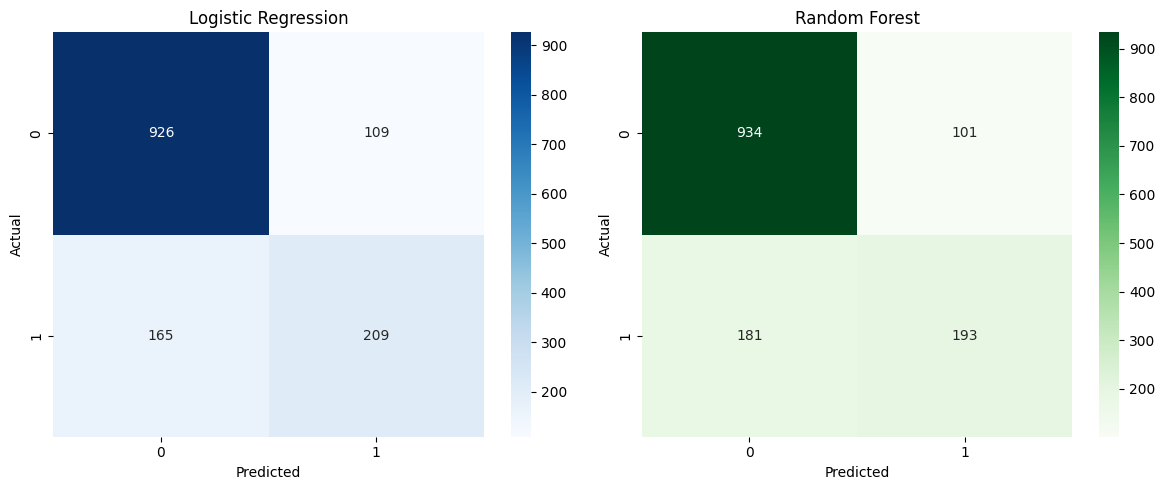

In [11]:
# Create side-by-side confusion matrix plots for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix for Logistic Regression
cm_logreg = confusion_matrix(y_test, logreg_preds)
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()  # avoids overlapping labels
plt.show()          # renders the plots inline in Colab

**11: Pick the best model and export with joblib**

In [12]:
# Compare F1 scores to decide which pipeline performed better on test data
logreg_f1 = f1_score(y_test, logreg_preds)
rf_f1 = f1_score(y_test, rf_preds)

# Select whichever model scored higher
best_model = logreg_grid.best_estimator_ if logreg_f1 >= rf_f1 else rf_grid.best_estimator_
best_name = "Logistic Regression" if logreg_f1 >= rf_f1 else "Random Forest"

print(f"Best model: {best_name}")

# Save the ENTIRE pipeline (preprocessing + trained model) as one file
# This means anyone loading this file can predict on raw new data directly —
# no need to manually re-scale or re-encode inputs first
joblib.dump(best_model, "telco_churn_pipeline.joblib")

print("Pipeline saved as telco_churn_pipeline.joblib")

Best model: Logistic Regression
Pipeline saved as telco_churn_pipeline.joblib


**12: Test that the saved pipeline reloads and works correctly**

In [13]:
# Load the pipeline back from disk to confirm it works end-to-end
loaded_pipeline = joblib.load("telco_churn_pipeline.joblib")

# Run predictions on the test set using the reloaded pipeline
sample_preds = loaded_pipeline.predict(X_test.head(5))
print("Sample predictions from reloaded pipeline:", sample_preds)
print("Actual values:                            ", y_test.head(5).values)

Sample predictions from reloaded pipeline: [0 1 0 0 0]
Actual values:                             [0 0 0 0 0]
